In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample


In [2]:
df=pd.read_csv('glass.csv')

In [3]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0


In [5]:
df.shape



(999, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 78.2 KB


In [7]:
df.describe

<bound method NDFrame.describe of           RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0    1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0   1.0
1    1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0   1.0
2    1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0   1.0
3    1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0   1.0
4    1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0   1.0
..       ...    ...   ...   ...    ...   ...   ...  ...  ...   ...
994      NaN    NaN   NaN   NaN    NaN   NaN   NaN  NaN  NaN   NaN
995      NaN    NaN   NaN   NaN    NaN   NaN   NaN  NaN  NaN   NaN
996      NaN    NaN   NaN   NaN    NaN   NaN   NaN  NaN  NaN   NaN
997      NaN    NaN   NaN   NaN    NaN   NaN   NaN  NaN  NaN   NaN
998      NaN    NaN   NaN   NaN    NaN   NaN   NaN  NaN  NaN   NaN

[999 rows x 10 columns]>

In [8]:
df.isnull().sum()


RI      785
Na      785
Mg      785
Al      785
Si      785
K       785
Ca      785
Ba      785
Fe      785
Type    785
dtype: int64

In [30]:
df = df.dropna()
#Removal of rows has been performed because there are complete rows containing NaN values which are of no use,so better we remove those rows


In [10]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [11]:
df['Type'].value_counts()


Type
2.0    76
1.0    70
7.0    29
3.0    17
5.0    13
6.0     9
Name: count, dtype: int64

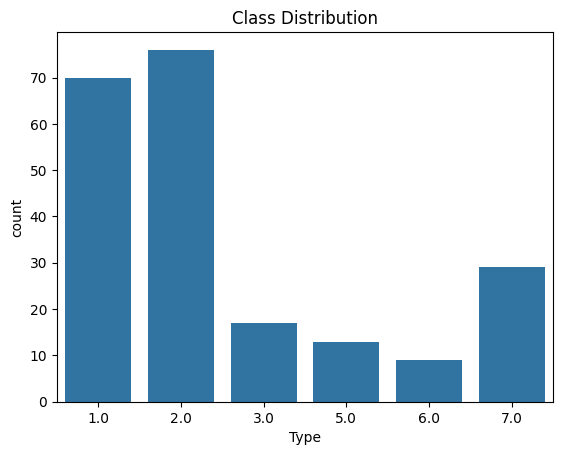

In [12]:
sns.countplot(x='Type', data=df)
plt.title("Class Distribution")
plt.show()


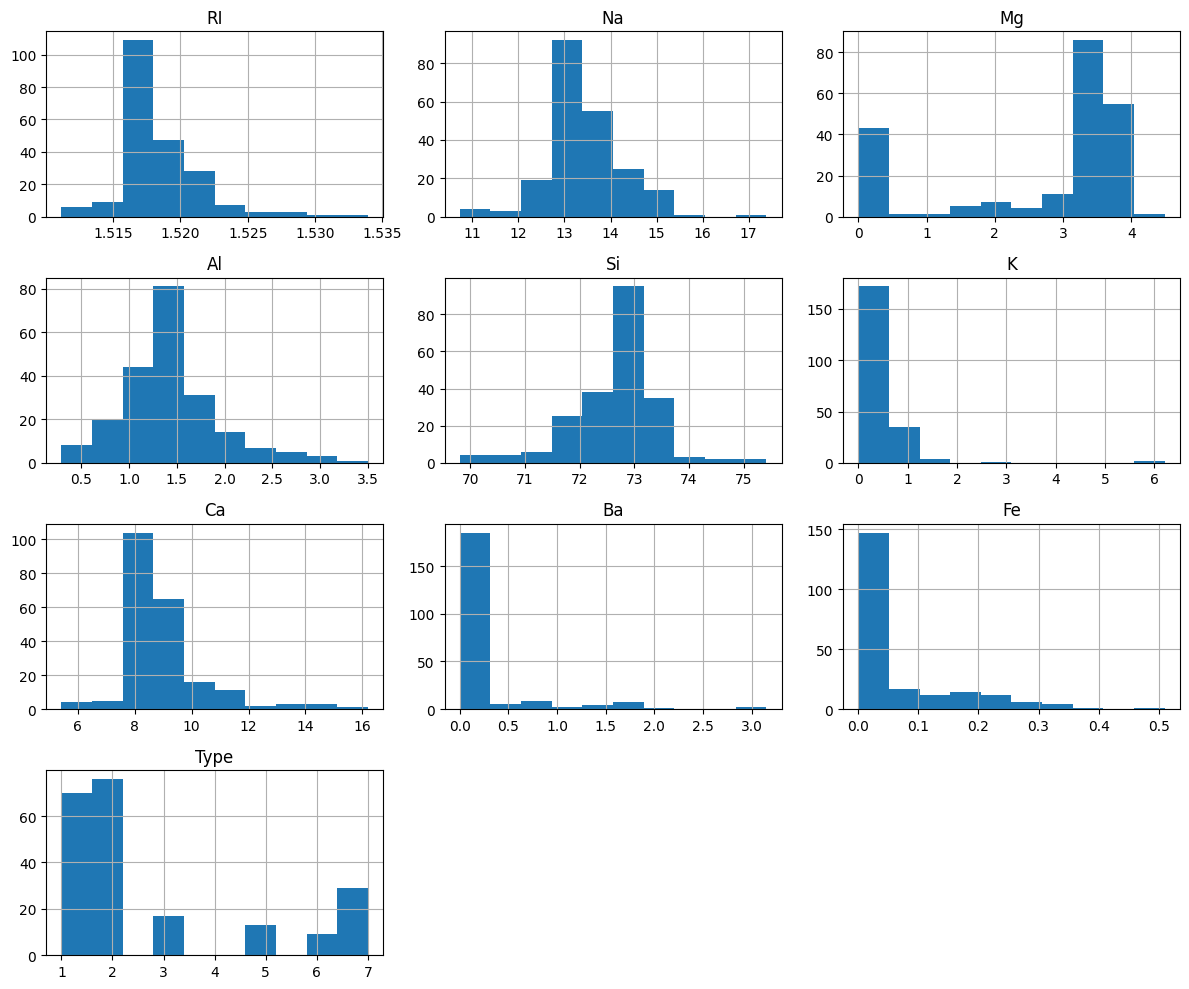

In [13]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()


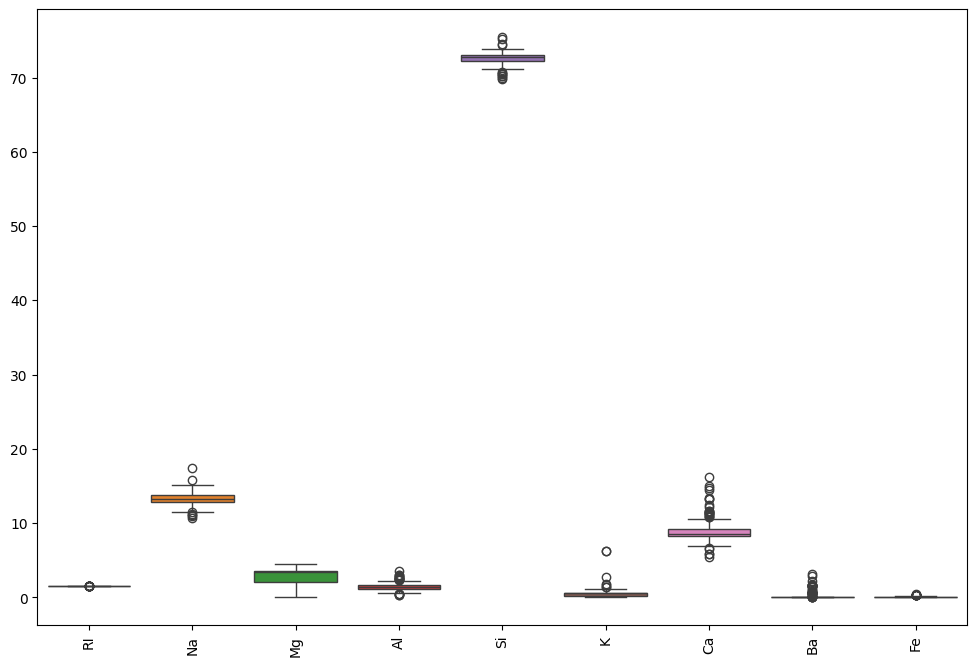

In [14]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df.drop('Type', axis=1))
plt.xticks(rotation=90)
plt.show()


In [18]:
num_cols = df.columns.drop('Type')

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df.loc[:, col] = df[col].clip(lower, upper)

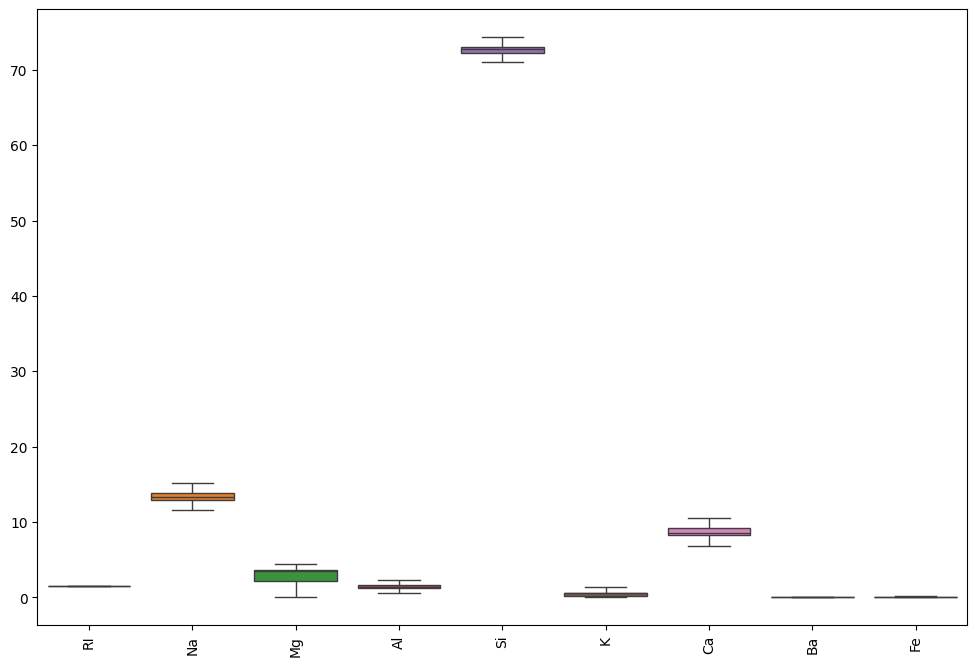

In [19]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df.drop('Type', axis=1))
plt.xticks(rotation=90)
plt.show()


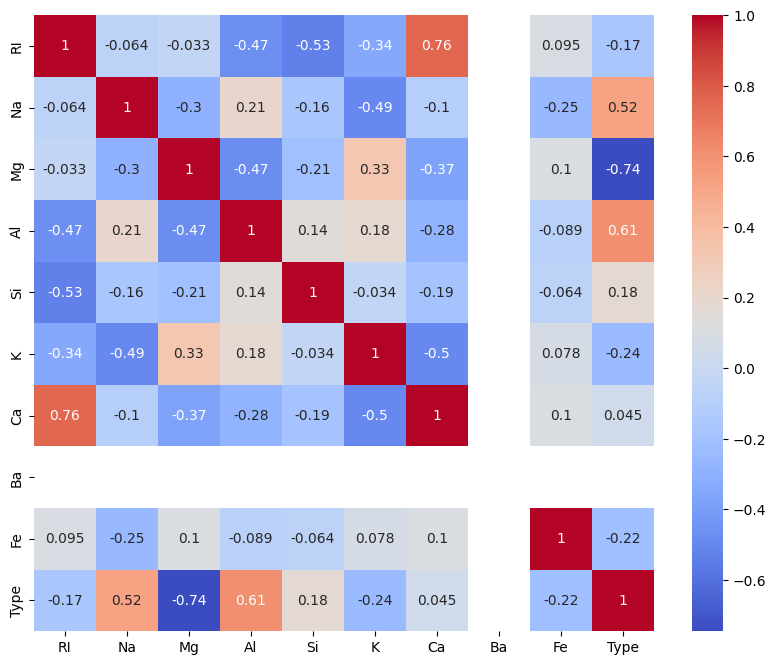

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


In [21]:
X = df.drop('Type', axis=1)
y = df['Type']


In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [23]:
class_weight='balanced'


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


In [26]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.7692307692307693

Classification Report:

              precision    recall  f1-score   support

         1.0       0.75      0.86      0.80        21
         2.0       0.84      0.70      0.76        23
         3.0       0.67      0.40      0.50         5
         5.0       0.67      1.00      0.80         4
         6.0       0.67      0.67      0.67         3
         7.0       0.80      0.89      0.84         9

    accuracy                           0.77        65
   macro avg       0.73      0.75      0.73        65
weighted avg       0.77      0.77      0.76        65


Confusion Matrix:

[[18  2  1  0  0  0]
 [ 3 16  0  2  1  1]
 [ 3  0  2  0  0  0]
 [ 0  0  0  4  0  0]
 [ 0  0  0  0  2  1]
 [ 0  1  0  0  0  8]]


In [27]:
bag_model = BaggingClassifier(
    n_estimators=100,
    random_state=42
)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag))


Bagging Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

         1.0       0.79      0.90      0.84        21
         2.0       0.80      0.70      0.74        23
         3.0       0.67      0.40      0.50         5
         5.0       0.60      0.75      0.67         4
         6.0       0.67      0.67      0.67         3
         7.0       0.80      0.89      0.84         9

    accuracy                           0.77        65
   macro avg       0.72      0.72      0.71        65
weighted avg       0.77      0.77      0.76        65



In [28]:
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))


AdaBoost Accuracy: 0.38461538461538464
              precision    recall  f1-score   support

         1.0       0.42      0.52      0.47        21
         2.0       0.37      0.30      0.33        23
         3.0       0.00      0.00      0.00         5
         5.0       0.00      0.00      0.00         4
         6.0       0.00      0.00      0.00         3
         7.0       0.64      0.78      0.70         9

    accuracy                           0.38        65
   macro avg       0.24      0.27      0.25        65
weighted avg       0.36      0.38      0.37        65



C:\Users\nalla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nalla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nalla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [29]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))


Random Forest Accuracy: 0.7692307692307693
Bagging Accuracy: 0.7692307692307693
AdaBoost Accuracy: 0.38461538461538464


### Explain Bagging and Boosting methods. How is it different from each other.

#### Bagging

Bagging is an ensemble technique where:

- Multiple models are trained independently

- Each model is trained on a different random sample (with replacement) of the dataset

- Final prediction is taken by majority voting (classification)

**Purpose:**

- Reduces variance

- Prevents overfitting

**Example:**

Random Forest is an advanced version of Bagging.

#### Boosting

Boosting is an ensemble technique where:

- Models are trained sequentially

- Each new model focuses on correcting errors made by previous models

- Final prediction is a weighted combination of all models

**Purpose:**

Reduces bias

Improves weak learners

**Example:**

AdaBoost, Gradient Boosting, XGBoost

### Explain how to handle imbalance in the data.

Imbalanced data means some classes have much more samples than others.

##### Methods to Handle Imbalance

**Resampling Techniques**

a) Oversampling

Increase minority class samples

Example: SMOTE

b) Undersampling

Reduce majority class samples

**Use Class Weights**

Assign higher weight to minority class

Example in Random Forest:

RandomForestClassifier(class_weight='balanced')

This tells the model to penalize mistakes on minority class more.

**Use Proper Evaluation Metrics**

Instead of only accuracy, use:

Precision

Recall

F1-score

Confusion Matrix

Because accuracy can be misleading in imbalanced datasets.